In [4]:
import numpy as np
import pandas as pd
import joblib
import sqlalchemy as db
from src.get_all_data import get_all_data
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

In [5]:
#Load Models
hmm = joblib.load('../models/hmm_model.pkl')
pca = joblib.load('../models/pca.pkl')
scaler = joblib.load('../models/scaler.pkl')
meta_model = joblib.load('../models/meta_model.pkl')

n_states = hmm.n_components

In [6]:
#load data
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-06-17 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-04-10 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-04-14 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-04-09 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Advance GD

In [7]:
#prepare for hmm
X_scaled = scaler.transform(df)
X_pca = pca.transform(X_scaled)
state_probs = hmm.predict_proba(X_pca)
state_pred = hmm.predict(X_pca)

df['state'] = state_pred
df['confidence'] = state_probs.max(axis=1)
df['entropy'] = -np.sum(state_probs * np.log(state_probs + 1e-8), axis=1)

for i in range(n_states):
    df[f'prob_state_{i}'] = state_probs[:, i]

In [8]:
#meta model datas
duration, count = [], 1
for i in range(len(df)):
    if i == 0:
        duration.append(1)
    elif df['state'].iloc[i] == df['state'].iloc[i - 1]:
        count += 1
        duration.append(count)
    else:
        count = 1
        duration.append(1)
df['state_duration'] = duration

ROLL = 5
df['confidence_roll'] = df['confidence'].rolling(ROLL).mean()
for i in range(n_states):
    df[f'prob_state_{i}_roll'] = df[f'prob_state_{i}'].rolling(ROLL).mean()

meta_features = ['confidence', 'entropy', 'state_duration', 'confidence_roll'] + \
                [f'prob_state_{i}_roll' for i in range(n_states)]

df = df.dropna(subset=meta_features)

final_states = []
for i in range(len(df)):
    if i == 0:
        final_states.append(df['state'].iloc[i])
        continue
    curr = df['state'].iloc[i]
    prev = final_states[-1]
    if curr != prev:
        X_t   = df.iloc[i][meta_features].values.reshape(1, -1)
        proba = meta_model.predict_proba(X_t)[0][1]
        final_states.append(curr if proba > 0.75 else prev)
    else:
        final_states.append(curr)

df['filtered_state'] = final_states

df['returns'] = df['spy_close'].pct_change()
df = df.dropna(subset=['returns'])

C:\Users\usuario\Desktop\Python\Market Regime\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\usuario\Desktop\Python\Market Regime\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\usuario\Desktop\Python\Market Regime\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\usuario\Desktop\Python\Market Regime\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\usuario\Desktop\Python\Market Regime\.venv\Lib\site-packages\sklearn\utils\vali

In [9]:
df['volatility_30'] = df['returns'].rolling(window=30).std()
df['rolling_sharpe'] = df['returns'].rolling(window=30).mean() / (df['volatility_30'] + 1e-8)

meta_features = ['filtered_state', 'confidence', 'entropy', 'state_duration',
                 'volatility_30', 'rolling_sharpe', 'spy_RSI_14']

df = df.dropna(subset=meta_features + ['returns']).reset_index(drop=True)

In [10]:
class DynamicPositionSizingEnv(gym.Env):
    def __init__(self, dataframe, initial_balance=10000):
        super(DynamicPositionSizingEnv, self).__init__()
        self.df = dataframe
        self.initial_balance = initial_balance

        # Acción: % de exposición (0.0 a 1.0)
        self.action_space = spaces.Box(low=0, high=1, shape=(1,), dtype=np.float32)

        # Observación: Las features del mercado
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(len(meta_features),), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.balance = self.initial_balance
        self.last_action = 0.0  # Para penalizar cambios bruscos
        return self._get_obs(), {}

    def _get_obs(self):
        return self.df.iloc[self.current_step][meta_features].values.astype(np.float32)

    def step(self, action):
        # 1. Escalar acción (el modelo entrega un array)
        target_size = action[0]

        # 2. Obtener datos del mercado
        market_return = self.df.iloc[self.current_step]['returns']

        # 3. Calcular Retorno de Cartera
        portfolio_return = target_size * market_return

        # 4. PENALIZACIONES (Aquí ocurre la magia del sizing dinámico)
        # A. Costo por mover la posición (evita el "flickering" o ruido)
        transaction_cost = abs(target_size - self.last_action) * 0.0005

        # B. Penalización por riesgo (Varianza): Castiga el "All-in" en activos volátiles
        risk_penalty = 0.5 * (portfolio_return**2)

        # 5. Recompensa Final
        reward = portfolio_return - transaction_cost - risk_penalty

        # Actualizar cuenta
        self.balance *= (1 + portfolio_return - transaction_cost)
        self.last_action = target_size

        # Avanzar
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        truncated = self.balance <= (self.initial_balance * 0.3) # Stop Out al 70% de pérdida

        return self._get_obs(), float(reward), terminated, truncated, {}

In [11]:
# 1. Crear el entorno
env = DynamicPositionSizingEnv(df)

# 2. Configurar el modelo PPO
model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=0.0002,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,          # Factor de descuento
    ent_coef=0.02,       # CLAVE: Obliga a no ser binario (0 o 1)
    verbose=1
)

# 3. Entrenar (Prueba con 100k pasos para empezar)
print("Iniciando entrenamiento...")
model.learn(total_timesteps=100000)

# 4. Guardar el cerebro
model.save("position_sizing_agent")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Iniciando entrenamiento...
-----------------------------
| time/              |      |
|    fps             | 1073 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 2.24e+03     |
|    ep_rew_mean          | 0.845        |
| time/                   |              |
|    fps                  | 897          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0019993293 |
|    clip_fraction        | 0.00713      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | -0.0672      |
|    learning_rate      


==================== BACKTEST REPORT ====================
  Rentabilidad Total : +43.23%
  Sharpe Ratio Anual : 5.381
  Max Drawdown       : -2.54%
  Exposición Media   : 74.58%
  Cambios de Sizing  : 34



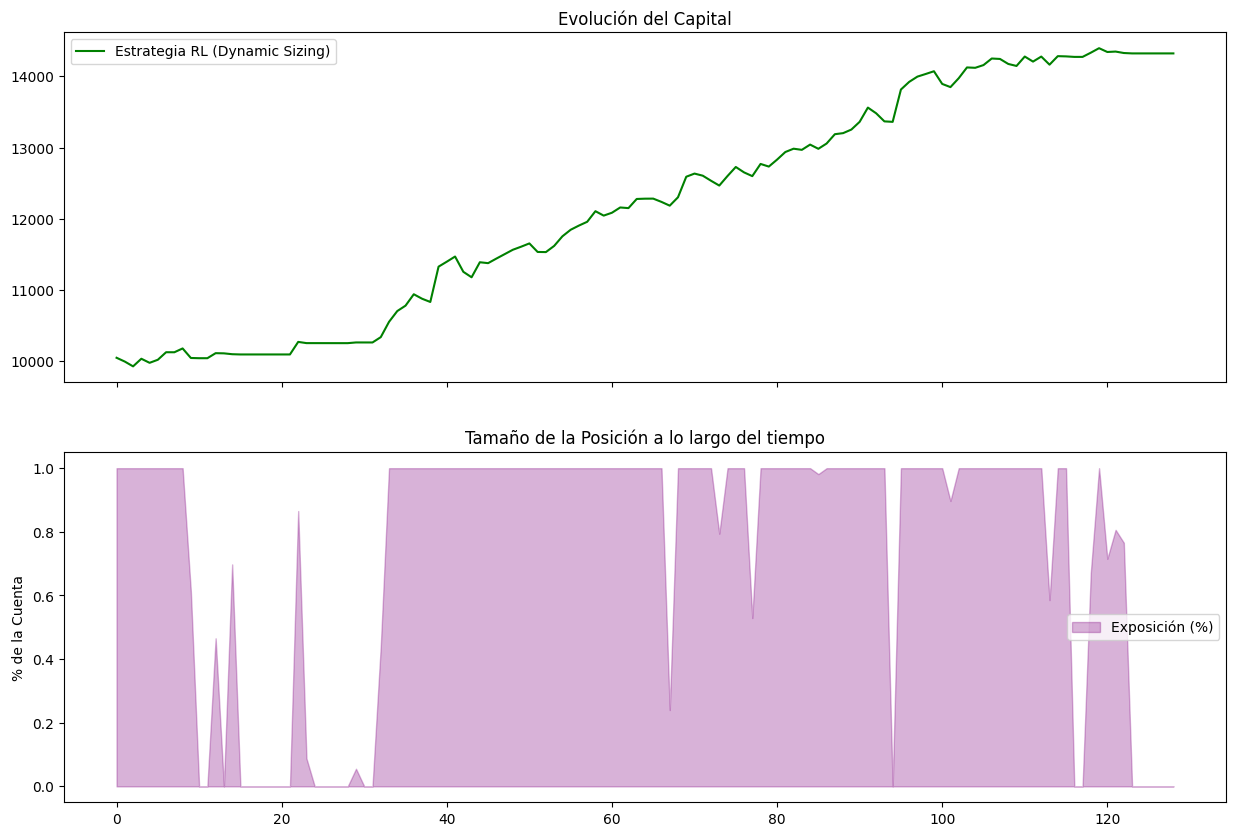

In [18]:
import matplotlib.pyplot as plt

def run_episode(model, df_eval, initial_capital=10000, deterministic=True):
    """
    Ejecuta un episodio completo de evaluación y devuelve métricas detalladas.
    """
    # Instanciamos el entorno de evaluación con los datos de test
    env = DynamicPositionSizingEnv(df_eval, initial_balance=initial_capital)
    obs, _ = env.reset()

    # Listas para almacenar el histórico
    positions = []
    portfolio_vals = []
    daily_returns = []
    regimes = []

    done = False

    while not done:
        # El modelo decide el % de la posición
        action, _ = model.predict(obs, deterministic=deterministic)

        # Guardamos la posición ANTES del step para el registro (o info del env)
        current_pos = action[0]

        obs, reward, terminated, truncated, info = env.step(action)

        # Guardar métricas
        positions.append(current_pos)
        portfolio_vals.append(env.balance)
        # Calculamos el retorno porcentual diario de la cartera
        if len(portfolio_vals) > 1:
            ret = (portfolio_vals[-1] / portfolio_vals[-2]) - 1
            daily_returns.append(ret)
        else:
            daily_returns.append(0.0)

        regimes.append(df_eval['filtered_state'].iloc[env.current_step - 1])

        done = terminated or truncated

    # --- Cálculos de Métricas Finales ---
    daily_returns = np.array(daily_returns)
    portfolio_vals = np.array(portfolio_vals)

    # Sharpe Ratio Anualizado (asumiendo 252 días comerciales)
    sharpe = (daily_returns.mean() / (daily_returns.std() + 1e-8)) * np.sqrt(252)

    # Retorno Total
    total_ret = (portfolio_vals[-1] / initial_capital - 1) * 100

    # Drawdown Máximo
    peak = np.maximum.accumulate(portfolio_vals)
    drawdown = (portfolio_vals - peak) / peak
    max_dd = drawdown.min() * 100

    print(f"\n{'='*20} BACKTEST REPORT {'='*20}")
    print(f"  Rentabilidad Total : {total_ret:+.2f}%")
    print(f"  Sharpe Ratio Anual : {sharpe:.3f}")
    print(f"  Max Drawdown       : {max_dd:.2f}%")
    print(f"  Exposición Media   : {np.mean(positions)*100:.2f}%")
    print(f"  Cambios de Sizing  : {(np.diff(np.round(positions, 2)) != 0).sum()}")
    print(f"{'='*57}\n")

    return np.array(positions), portfolio_vals, np.array(regimes)

# --- Ejecución y Visualización ---
positions, portfolio_vals, regimes = run_episode(model, df.iloc[-130:])

# Graficar resultados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Gráfico 1: Valor de la Cartera vs Buy & Hold (opcional si tienes el precio)
ax1.plot(portfolio_vals, label='Estrategia RL (Dynamic Sizing)', color='green')
ax1.set_title('Evolución del Capital')
ax1.legend()

# Gráfico 2: Exposición y Regímenes
ax2.fill_between(range(len(regimes)), 0, positions, alpha=0.3, color='purple', label='Exposición (%)')
ax2.set_title('Tamaño de la Posición a lo largo del tiempo')
ax2.set_ylabel('% de la Cuenta')
ax2.legend()

plt.show()